# 03 — Path Visualization (matplotlib 3D)

Renders the room geometry, furniture, anchor positions, and multipath trajectories from anchor_0 to the room centre using matplotlib 3D.

Sionna's built-in `scene.preview()` requires a WebGL viewer not available in standard Jupyter; this notebook uses a pure-Python fallback.

In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import sionna
import sionna.rt as rt
from sionna.rt import (PathSolver, Transmitter, Receiver, PlanarArray, InteractionType)

print(f"Sionna {sionna.__version__}")

Sionna 1.2.1


In [2]:
scene_path = os.path.abspath("../scene/room.xml")
scene = rt.load_scene(scene_path)
scene.frequency = 6.5e9

anchors_yaml = os.path.abspath("../../src/microuwb_bringup/config/anchors.yaml")
with open(anchors_yaml) as f:
    anchors = yaml.safe_load(f)["anchors"]

anchor_positions = np.array([[a["x"], a["y"], a["z"]] for a in anchors])
print(f"Scene loaded. {len(anchors)} anchors.")

Scene loaded. 5 anchors.


## Compute paths: anchor_0 → room centre

In [3]:
iso_array = PlanarArray(num_rows=1, num_cols=1,
                        vertical_spacing=0.5, horizontal_spacing=0.5,
                        pattern="iso", polarization="V")
scene.tx_array = iso_array
scene.rx_array = iso_array

TX = anchor_positions[0].tolist()
RX = [2.5, 2.0, 1.0]

scene.add(Transmitter(name="tx", position=TX))
scene.add(Receiver(name="rx",   position=RX))

solver = PathSolver()
paths = solver(scene, max_depth=3, los=True,
               specular_reflection=True, diffuse_reflection=False,
               refraction=False, diffraction=False,
               samples_per_src=int(5e5))

valid_mask = np.array(paths.valid).squeeze().astype(bool)
print(f"Valid paths: {valid_mask.sum()}")

Valid paths: 59


## Build matplotlib 3D figure

Scene geometry drawn


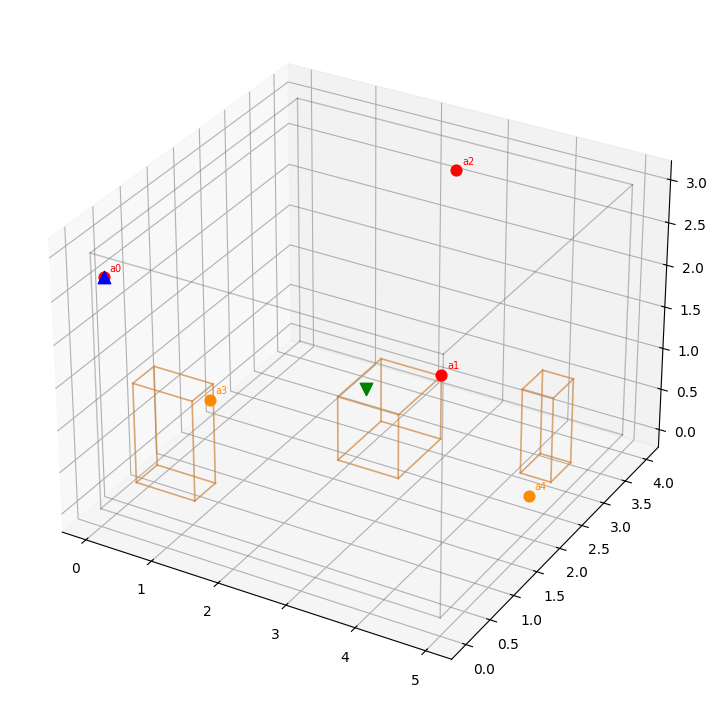

In [4]:
def draw_box_edges(ax, x0, x1, y0, y1, z0, z1, color="steelblue", lw=0.8, alpha=0.5):
    pts = np.array([
        [x0,y0,z0],[x1,y0,z0],[x1,y1,z0],[x0,y1,z0],
        [x0,y0,z1],[x1,y0,z1],[x1,y1,z1],[x0,y1,z1],
    ])
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i,j in edges:
        ax.plot(*zip(pts[i], pts[j]), color=color, lw=lw, alpha=alpha)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Room envelope
draw_box_edges(ax, 0, 5, 0, 4, 0, 3, color="dimgray", lw=1.0, alpha=0.4)

# Furniture bounding boxes
FURNITURE = [
    ("bookshelf",  0.05, 0.95, 0.61, 1.01, 0.00, 1.20),
    ("cafe table", 2.044, 2.956, 2.044, 2.956, 0.00, 0.775),
    ("cabinet",    4.275, 4.725, 2.775, 3.225, 0.00, 1.02),
]
for label, *bounds in FURNITURE:
    draw_box_edges(ax, *bounds, color="peru", lw=1.2, alpha=0.7)

# Anchor positions
for i, pos in enumerate(anchor_positions):
    c = "red" if pos[2] > 1.5 else "darkorange"
    ax.scatter(*pos, color=c, s=60, zorder=5)
    ax.text(pos[0]+0.05, pos[1]+0.05, pos[2]+0.05, f"a{i}", fontsize=7, color=c)

# TX and RX
ax.scatter(*TX, color="blue", s=80, marker="^", zorder=6, label="TX (anchor_0)")
ax.scatter(*RX, color="green", s=80, marker="v", zorder=6, label="RX (room centre)")

print("Scene geometry drawn")

In [5]:
# Draw multipath trajectories using paths.vertices if available
# vertices shape: (max_depth, num_rx, num_tx, num_paths, 3)
tau_np = np.array(paths.tau).squeeze()

try:
    verts_np = np.array(paths.vertices)   # attempt (max_depth, ..., 3)
    has_verts = True
    # Collapse singleton tx/rx dims: (max_depth, num_paths, 3)
    while verts_np.ndim > 3 and verts_np.shape[1] == 1:
        verts_np = verts_np[:, 0, ...]
    while verts_np.ndim > 3 and verts_np.shape[2] == 1:
        verts_np = verts_np[:, :, 0, ...]
    print(f"paths.vertices available, shape after squeeze: {verts_np.shape}")
except AttributeError:
    has_verts = False
    print("paths.vertices not available — drawing direct TX→RX lines")

valid_idx = np.where(valid_mask)[0]
sorted_idx = valid_idx[np.argsort(tau_np[valid_mask])]
n_draw = min(20, len(sorted_idx))

cmap = plt.cm.plasma
for rank, pi in enumerate(sorted_idx[:n_draw]):
    color = cmap(rank / max(n_draw - 1, 1))
    alpha = max(0.15, 0.8 - rank * 0.03)

    if has_verts:
        # Build waypoint sequence: TX → bounce points → RX
        waypoints = [np.array(TX)]
        for depth in range(verts_np.shape[0]):
            v = verts_np[depth, pi, :]
            if np.any(np.isnan(v)) or np.all(v == 0):
                break
            waypoints.append(v)
        waypoints.append(np.array(RX))
        for k in range(len(waypoints) - 1):
            seg = np.array([waypoints[k], waypoints[k+1]])
            ax.plot(seg[:,0], seg[:,1], seg[:,2], color=color, lw=0.6, alpha=alpha)
    else:
        seg = np.array([TX, RX])
        ax.plot(seg[:,0], seg[:,1], seg[:,2], color=color, lw=0.6, alpha=alpha)

ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
ax.set_xlim(0, 5); ax.set_ylim(0, 4); ax.set_zlim(0, 3)
ax.set_title(f"Multipath: anchor_0 → room centre\n"
             f"({n_draw} paths shown, coloured shortest→longest)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()

RENDERS = os.path.abspath("../renders")
os.makedirs(RENDERS, exist_ok=True)
out = os.path.join(RENDERS, "03_multipath_3d.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()
print(f"Saved: {out}")

paths.vertices available, shape after squeeze: (3, 59, 3)
Saved: /home/avg_shilp_kid/microuwb_nav_ws/sionna_precompute/renders/03_multipath_3d.png


## LOS coverage overview — slice at z = 1.5 m (coarse)

Quick sample: check LOS/NLOS for a 10×8 coarse grid from all 5 anchors.

In [6]:
scene.remove("tx")
scene.remove("rx")

xs = np.linspace(0.5, 4.5, 9)
ys = np.linspace(0.5, 3.5, 7)
Z_SLICE = 1.5
XX, YY = np.meshgrid(xs, ys)
pts = np.stack([XX.ravel(), YY.ravel(), np.full(XX.size, Z_SLICE)], axis=1)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for anc_idx, anc in enumerate(anchors):
    anc_pos = [float(anc["x"]), float(anc["y"]), float(anc["z"])]

    try:
        scene.remove("tx")
    except Exception:
        pass

    scene.add(Transmitter(name="tx", position=anc_pos))
    los_grid = np.zeros(len(pts), dtype=bool)

    for ri, pt in enumerate(pts):
        try:
            scene.remove("rx")
        except Exception:
            pass
        scene.add(Receiver(name="rx", position=pt.tolist()))

        p = solver(scene, max_depth=3, los=True, specular_reflection=True,
                   diffuse_reflection=False, refraction=False, diffraction=False,
                   samples_per_src=int(1e5))

        v = np.array(p.valid).squeeze().astype(bool)
        tau_i = np.array(p.tau).squeeze()
        if v.any():
            fi = int(np.argmin(tau_i[v]))
            inter_i = np.array(p.interactions)
            md_i = inter_i.shape[0]; np_i = inter_i.shape[-1]
            inter2d = inter_i.reshape(md_i, -1, np_i)[:, 0, :]
            fpi = inter2d[:, np.where(v)[0][fi]]
            los_grid[ri] = bool(np.all(fpi == InteractionType.NONE))

    try:
        scene.remove("rx")
    except Exception:
        pass

    los_map = los_grid.reshape(len(ys), len(xs))
    ax = axes[anc_idx]
    im = ax.imshow(los_map, origin="lower", extent=[0.5, 4.5, 0.5, 3.5],
                   cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.scatter(*anc_pos[:2], c="blue", s=50, marker="^", zorder=5)
    ax.set_title(f"anchor_{anc_idx}\n({anc_pos[0]},{anc_pos[1]},{anc_pos[2]})", fontsize=8)
    ax.set_xlabel("X (m)")
    if anc_idx == 0:
        ax.set_ylabel("Y (m)")
    los_pct = 100 * los_grid.mean()
    ax.set_xlabel(f"LOS: {los_pct:.0f}%")

plt.suptitle(f"LOS/NLOS at z={Z_SLICE}m (green=LOS, red=NLOS)", fontsize=10)
plt.tight_layout()
out = os.path.join(RENDERS, "03_los_coverage_slice.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()
print(f"Saved: {out}")

Saved: /home/avg_shilp_kid/microuwb_nav_ws/sionna_precompute/renders/03_los_coverage_slice.png
